In [3]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import json


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
subset, _ = random_split(data, [1000, len(data)-1000])
train_set, val_set = random_split(subset, [800, 200])

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64)


In [6]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [7]:
train_losses, val_losses = [], []

for epoch in range(5):
    model.train()
    total_loss = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss / len(train_loader))

   
    model.eval()
    correct, val_loss = 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            val_loss += loss_fn(out, y).item()
            correct += (out.argmax(1) == y).sum().item()
    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f} | Val Loss={val_losses[-1]:.4f}")


Epoch 1: Train Loss=2.0787 | Val Loss=1.7789
Epoch 2: Train Loss=1.4392 | Val Loss=1.2466
Epoch 3: Train Loss=0.9303 | Val Loss=0.8976
Epoch 4: Train Loss=0.6544 | Val Loss=0.7196
Epoch 5: Train Loss=0.4957 | Val Loss=0.6620


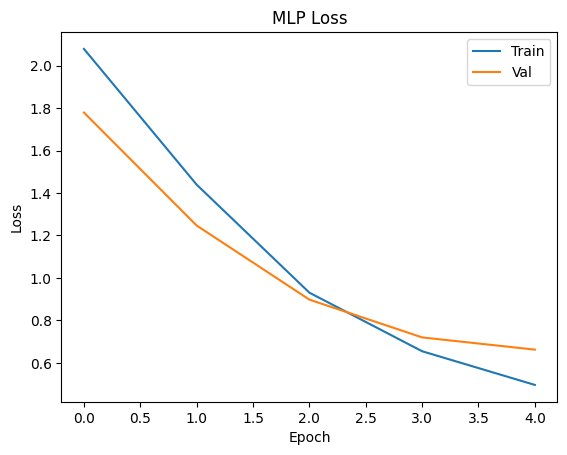

In [8]:
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Loss")
plt.legend()
plt.savefig("mlp_loss.png")
plt.show()


In [9]:
metrics = {
    "val_accuracy": round(correct / len(val_set), 4),
    "train_loss": round(train_losses[-1], 4),
    "val_loss": round(val_losses[-1], 4)
}

with open("mlp_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

metrics


{'val_accuracy': 0.85, 'train_loss': 0.4957, 'val_loss': 0.662}